# Image Enhancement for selected poor quality images

In this Project: you are given some selected poor quality images.

It is required to select and apply suitable enhancement technique(s) to
enhance each image in order to achieve the required task.

**[1] Component Extraction from the following images**

• Circle

• COVID‐19 Chart


###   For the circle we will use morphological operation

In [ ]:
import kagglehub
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.image as mpimg
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bosyayman202202076/images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/images


## Show the Image

In [ ]:
def show_image(image, title="", cmap=None):
    plt.figure(figsize=(8, 8))
    if cmap:
        plt.imshow(image, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

# 7 Circles

In [ ]:
image_path = os.path.join(path, "7 circles.png")
img = cv2.imread(image_path)
output = img.copy()

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


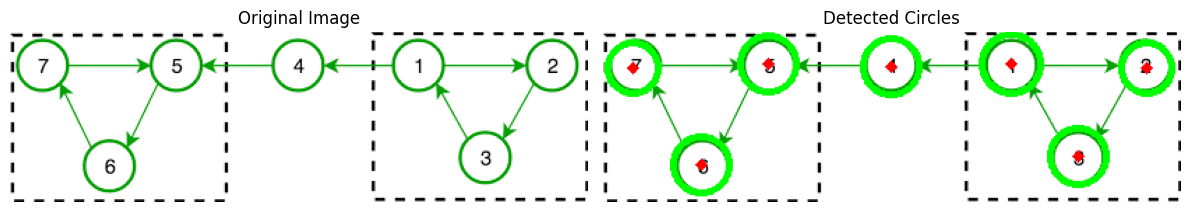

In [ ]:

circle_img_path = os.path.join(path, "7 circles.png")
circle_img = cv2.imread(circle_img_path)
gray_circle = cv2.cvtColor(circle_img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to reduce noise
blurred_circle = cv2.GaussianBlur(gray_circle, (9, 9), 2)

# Detect Circles using Hough Circle Transform
detected_circles = cv2.HoughCircles(
    blurred_circle,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=40,
    param1=50,
    param2=30,
    minRadius=10,
    maxRadius=40
)

# Draw Circles on Image
output_circle = circle_img.copy()
if detected_circles is not None:
    detected_circles = np.uint16(np.around(detected_circles))
    for circle in detected_circles[0, :]:
        center = (circle[0], circle[1])
        radius = circle[2]
        cv2.circle(output_circle, center, radius, (0, 255, 0), 3)
        cv2.circle(output_circle, center, 2, (0, 0, 255), 3)  # center dot


### Show the image with circles


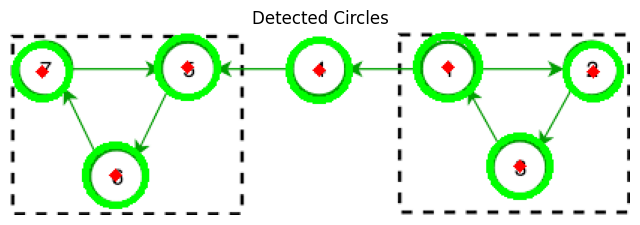

In [ ]:
show_image(output_circle, "Detected Circles")

# Covid

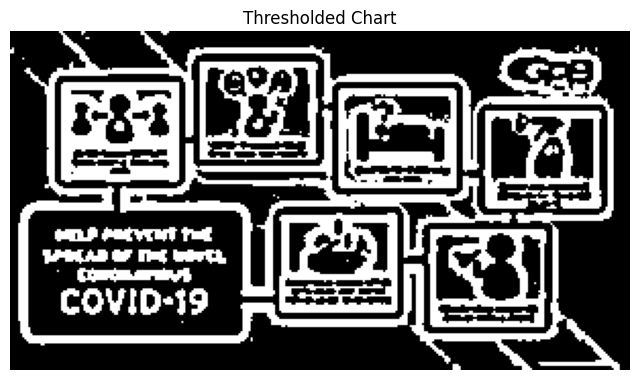

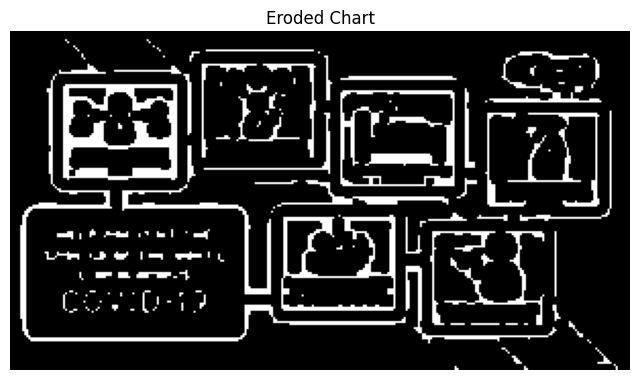

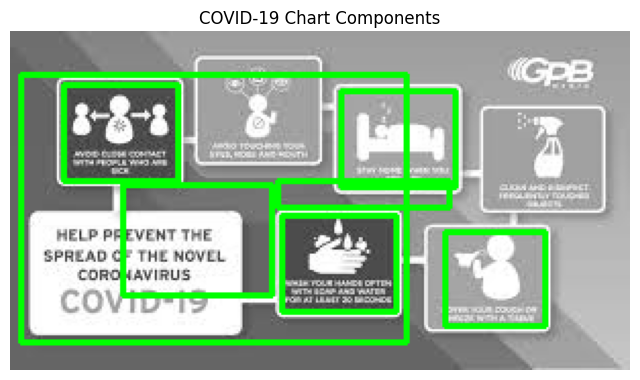

In [ ]:
chart_img_path = os.path.join(path, "/kaggle/input/images/Multi_objects_separation.jpeg")
chart_img = cv2.imread(chart_img_path, cv2.IMREAD_GRAYSCALE)

# Preprocess: Denoise using Gaussian Blur
blurred_chart = cv2.GaussianBlur(chart_img, (5, 5), 0)

# Adaptive Thresholding to isolate shapes
binary_chart = cv2.adaptiveThreshold(
    blurred_chart,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11,
    2
)

# Morphological Erosion to remove small noise
kernel = np.ones((3, 3), np.uint8)
eroded_chart = cv2.erode(binary_chart, kernel, iterations=1)

# Extract External Contours
contours, _ = cv2.findContours(
    eroded_chart,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Draw Bounding Boxes for Large Enough Contours
output_chart = cv2.cvtColor(chart_img, cv2.COLOR_GRAY2BGR)
min_area = 100
for contour in contours:
    if cv2.contourArea(contour) > min_area:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(output_chart, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Show Intermediate & Final Results
show_image(binary_chart, "Thresholded Chart", cmap='gray')
show_image(eroded_chart, "Eroded Chart", cmap='gray')
show_image(output_chart, "COVID-19 Chart Components")

# [2] Enhancement of Blurry Images

• Buildings

• Dog

# Buildings

In [ ]:
image_path4 = os.path.join(path, "/kaggle/input/images/Building.jpg")

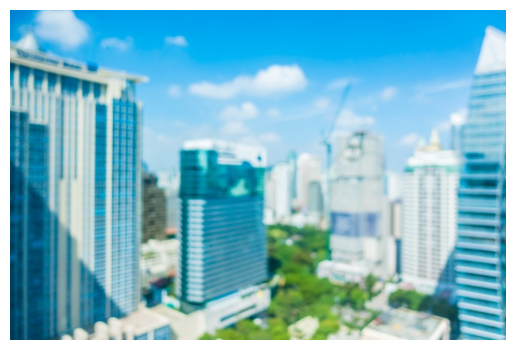

In [ ]:
ShowImg(image_path4)

###  Using High pass Filter

In [ ]:

# Load and convert to RGB
building_path = os.path.join(path, "Building.jpg")
building_img = cv2.imread(building_path)
building_rgb = cv2.cvtColor(building_img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray_building = cv2.cvtColor(building_img, cv2.COLOR_BGR2GRAY)

# High-pass filter kernel for edge emphasis
high_pass_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# Apply high-pass filter
filtered_building = cv2.filter2D(gray_building, -1, high_pass_kernel)

# Convert to RGB for blending
filtered_colored = cv2.cvtColor(filtered_building, cv2.COLOR_GRAY2RGB)

# Combine original with filtered image
enhanced_building = cv2.addWeighted(building_rgb, 1, filtered_colored, 1, 0)


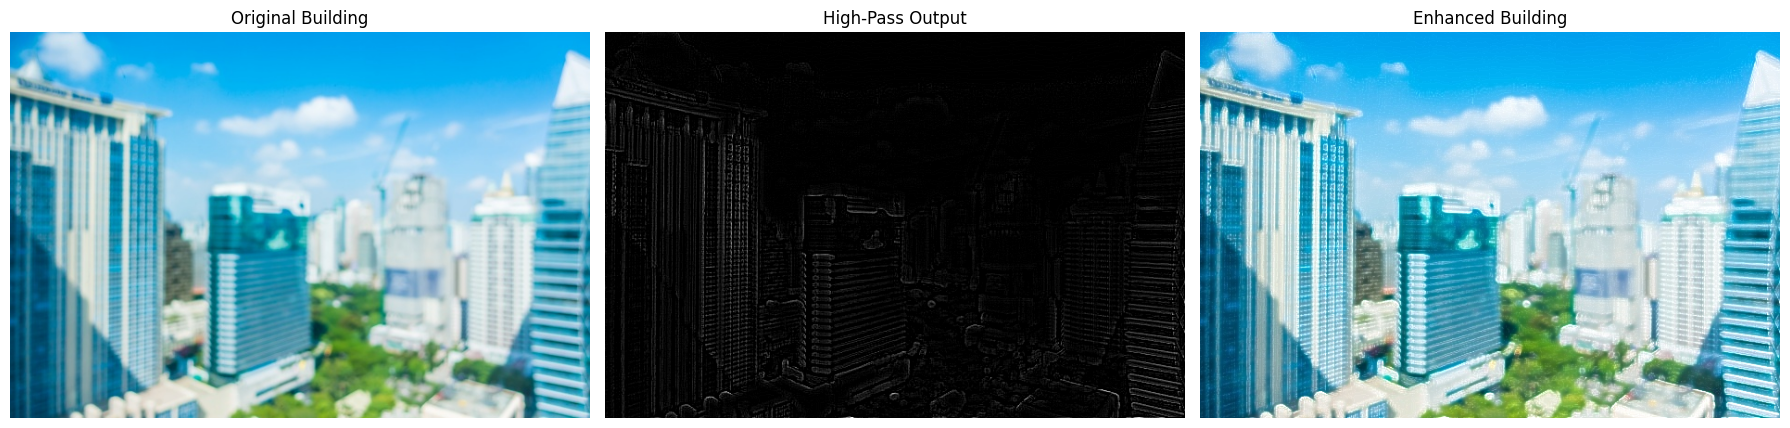

In [ ]:
# Display results
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(building_rgb)
plt.title("Original Building")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(filtered_colored)
plt.title("High-Pass Output")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(enhanced_building)
plt.title("Enhanced Building")
plt.axis('off')
plt.tight_layout()
plt.show()

# Dogs

In [ ]:

# Load and convert to RGB
dog_path = os.path.join(path, "Dog.jpeg")
dog_img = cv2.imread(dog_path)
dog_rgb = cv2.cvtColor(dog_img, cv2.COLOR_BGR2RGB)

# Sharpening kernel (emphasize edges and contrast)
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# Apply sharpening filter
sharpened_dog = cv2.filter2D(dog_rgb, -1, sharpen_kernel)

# Optional: blend sharpened with original for softer result
blended_dog = cv2.addWeighted(dog_rgb, 0.7, sharpened_dog, 0.3, 0)


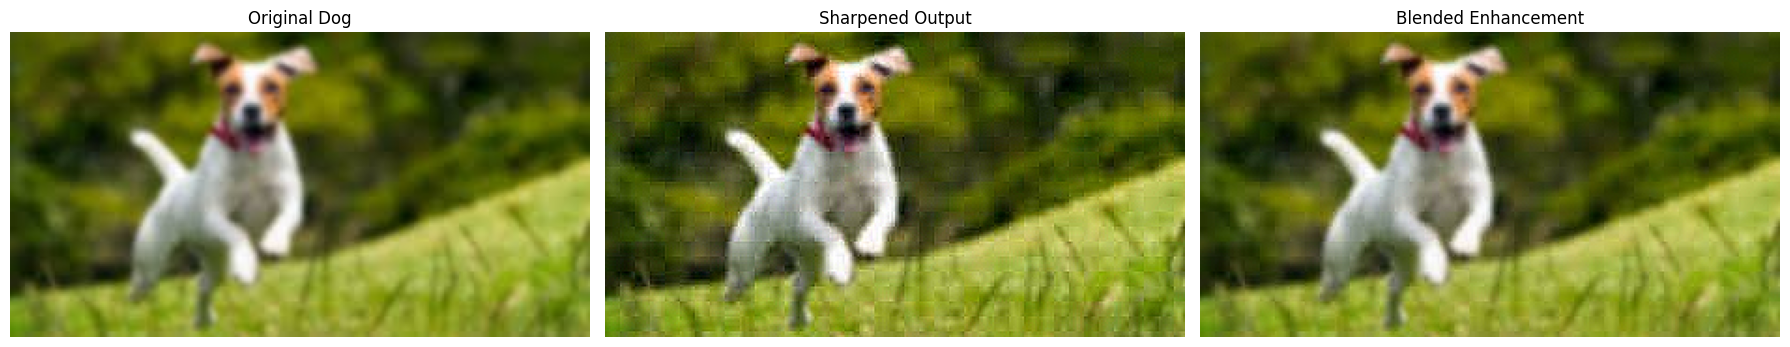

In [ ]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(dog_rgb)
plt.title("Original Dog")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpened_dog)
plt.title("Sharpened Output")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(blended_dog)
plt.title("Blended Enhancement")
plt.axis('off')
plt.tight_layout()
plt.show()

# [3] Noise removal from Noisy Images
• Text

• Rocket

• Wind Chart

# Text

In [ ]:
text_path = os.path.join(path, "Text.jpeg")
text_img = cv2.imread(text_path)
text_img_rgb = cv2.cvtColor(text_img, cv2.COLOR_BGR2RGB)


In [ ]:

# Apply Gaussian Blur
gaussian_text = cv2.GaussianBlur(text_img_rgb, (5, 5), 0)

# Apply Median Filtering
median_text = cv2.medianBlur(text_img_rgb, 5)

# Apply Non-Local Means Denoising
nlm_text = cv2.fastNlMeansDenoisingColored(text_img_rgb, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21)

# Show all results
titles_text = ['Original (Noisy)', 'Gaussian Blur', 'Median Filtering', 'Non-Local Means']
images_text = [text_img_rgb, gaussian_text, median_text, nlm_text]


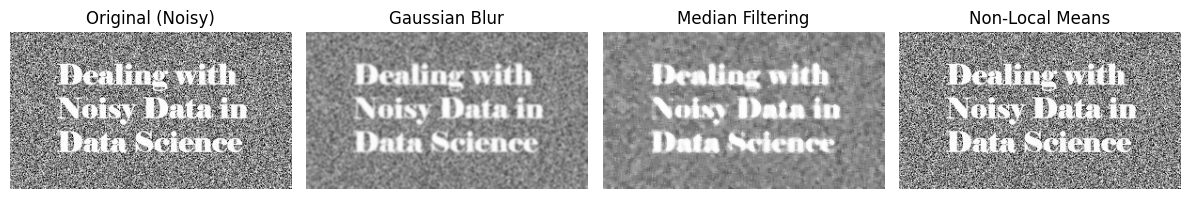

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images_text[i])
    plt.title(titles_text[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

# Rocket

In [ ]:
rocket_path = os.path.join(path, "Rocket.jpeg")
rocket_img = cv2.imread(rocket_path)
rocket_img_rgb = cv2.cvtColor(rocket_img, cv2.COLOR_BGR2RGB)


In [ ]:

# Apply Gaussian Blur
gaussian_rocket = cv2.GaussianBlur(rocket_img_rgb, (5, 5), 0)

# Apply Median Filtering
median_rocket = cv2.medianBlur(rocket_img_rgb, 5)

# Apply Non-Local Means Denoising
nlm_rocket = cv2.fastNlMeansDenoisingColored(rocket_img_rgb, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21)


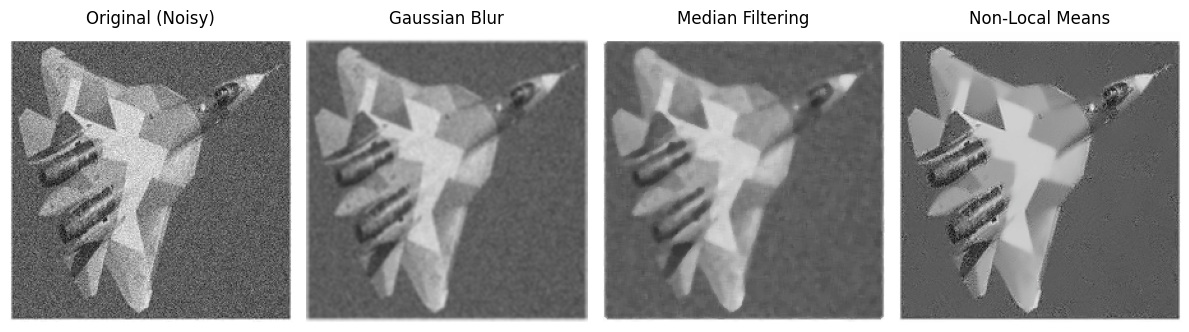

In [ ]:
titles_rocket = ['Original (Noisy)', 'Gaussian Blur', 'Median Filtering', 'Non-Local Means']
images_rocket = [rocket_img_rgb, gaussian_rocket, median_rocket, nlm_rocket]

plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images_rocket[i])
    plt.title(titles_rocket[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Wind Chart -> Noisy_1

In [ ]:
wind_chart_path = os.path.join(path, "Noisy_1.png")
wind_chart_img = cv2.imread(wind_chart_path)
wind_chart_img_rgb = cv2.cvtColor(wind_chart_img, cv2.COLOR_BGR2RGB)


In [ ]:

# Apply Gaussian Blur
gaussian_wind_chart = cv2.GaussianBlur(wind_chart_img_rgb, (5, 5), 0)

# Apply Median Filtering
median_wind_chart = cv2.medianBlur(wind_chart_img_rgb, 5)

# Apply Non-Local Means Denoising
nlm_wind_chart = cv2.fastNlMeansDenoisingColored(wind_chart_img_rgb, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21)



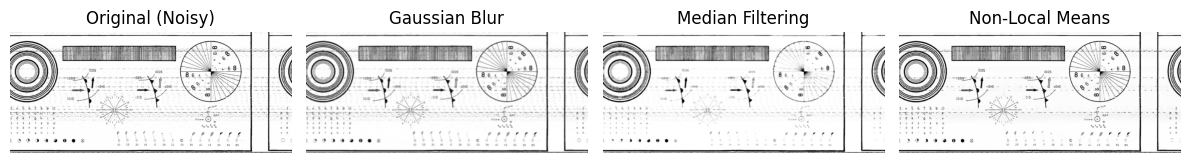

In [ ]:
titles_wind_chart = ['Original (Noisy)', 'Gaussian Blur', 'Median Filtering', 'Non-Local Means']
images_wind_chart = [wind_chart_img_rgb, gaussian_wind_chart, median_wind_chart, nlm_wind_chart]

plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images_wind_chart[i])
    plt.title(titles_wind_chart[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

# [4] Visual enhancement of the following images (Challenging Images)

• Newspaper

• Name Plate

# Newspaper -> Noisy_2

In [ ]:

# Load the noisy image (Newspaper image)
newspaper_path = os.path.join(path, "Noisy_2.jpg")
img_newspaper = cv2.imread(newspaper_path, cv2.IMREAD_COLOR)

# Apply Gaussian Blur
img_newspaper_gaussian = cv2.GaussianBlur(img_newspaper, (5, 5), 0)

# Apply Sharpening Filter
sharpen_kernel = np.array([[0, -1, 0],
                           [-1,  5, -1],
                           [0, -1, 0]])

img_newspaper_sharpened = cv2.filter2D(img_newspaper, -1, sharpen_kernel)
img_newspaper_sharpened_from_gaussian = cv2.filter2D(img_newspaper_gaussian, -1, sharpen_kernel)

# Show the results (Before and After Comparison)
plt.figure(figsize=(20, 20))

# Before Enhancement (Original Image)
plt.subplot(1, 3, 1)
plt.imshow(img_newspaper[:, :, ::-1], vmin=0, vmax=255)
plt.title("Before Enhancement (Original Image)")
plt.axis('off')

# After Enhancement (Sharpened Original)
plt.subplot(1, 3, 2)
plt.imshow(img_newspaper_sharpened[:, :, ::-1], vmin=0, vmax=255)
plt.title("After Enhancement (Sharpened Original)")
plt.axis('off')

# After Enhancement (Sharpened from Gaussian)
plt.subplot(1, 3, 3)
plt.imshow(img_newspaper_sharpened_from_gaussian[:, :, ::-1], vmin=0, vmax=255)
plt.title("After Enhancement (Sharpened from Gaussian)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Name Plate

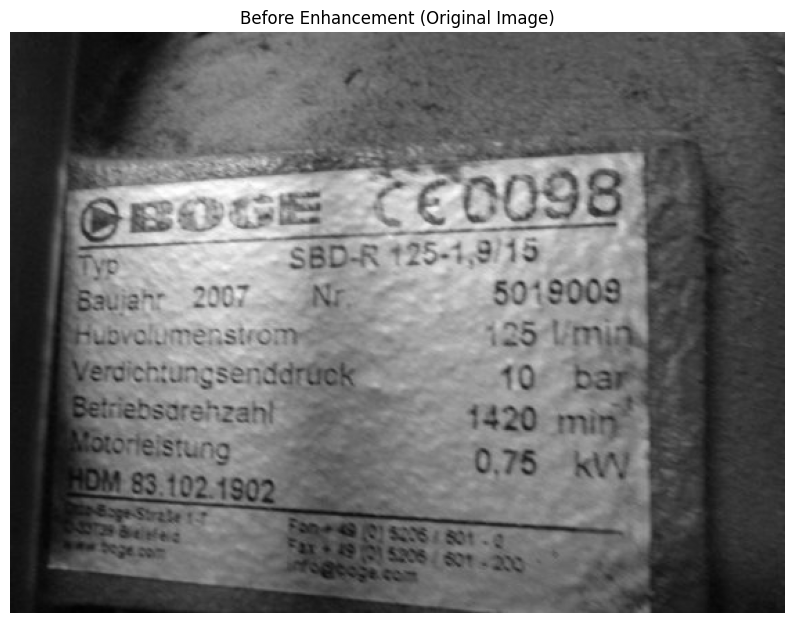

In [ ]:
nameplate_path = os.path.join(path, "Name plate.jpg")
img_nameplate = cv2.imread(nameplate_path, 0)

# Original Image
plt.figure(figsize=(10, 10))
plt.imshow(img_nameplate, cmap='gray', vmin=0, vmax=255)
plt.title("Before Enhancement (Original Image)")
plt.axis('off')
plt.show()



### Apply Histogram Equalization to improve contrast


In [ ]:
img_nameplate_eq = cv2.equalizeHist(img_nameplate)


### Apply Sharpening Filter


In [ ]:
sharpen_kernel_nameplate = np.array([[0, -1, 0],
                                     [-1, 5, -1],
                                     [0, -1, 0]])

img_nameplate_sharpened = cv2.filter2D(img_nameplate_eq, -1, sharpen_kernel_nameplate)

### After Enhancement


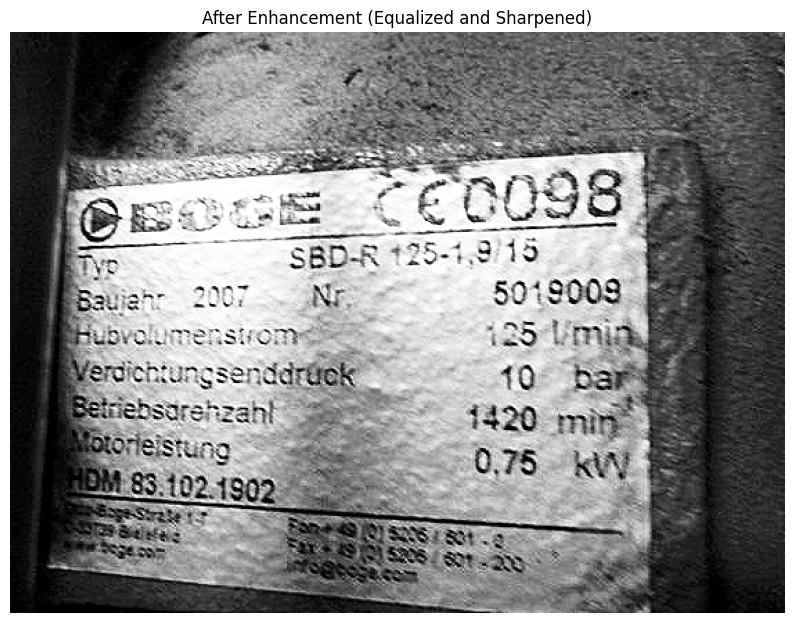

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(img_nameplate_sharpened, cmap='gray', vmin=0, vmax=255)
plt.title("After Enhancement (Equalized and Sharpened)")
plt.axis('off')
plt.show()
